<a href="https://colab.research.google.com/github/ted-chang80/AIFFEL_quest_eng/blob/main/MLOps/day6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Q1. API Key 인증이 없으면 어떤 위험이 있습니까?

**가장 먼저, 누구나 — 외부의 악의적인 사용자나 봇까지도 — 제한 없이 API를 호출할 수 있게 돼요. 모델 추론은 CPU/GPU 자원을 쓰는 작업이라 누군가 짧은 시간에 수천 번 호출하면 서버 자원이 고갈되거나(DoS) 비용이 급격히 늘어날 수 있어요. 또 "누가" 요청했는지 알 수 없으니, verify_api_key가 반환하는 사용자 이름으로 logger.info(f"추론 요청 — 사용자: {user}...") 처럼 요청자를 로그에 남기거나 사용자별 호출량을 제한하는 것도 불가능해집니다. 문제가 생겼을 때(예: 이상한 데이터로 모델을 망가뜨리려는 시도) 누구 짓인지 추적할 방법도 없어지죠.**

##Q2. Depends(verify_api_key)는 엔드포인트 실행 전에 어떤 일을 합니까?

**predict_image 함수는 user: str = Depends(verify_api_key)로 선언돼 있죠. 요청이 들어오면 FastAPI는 predict_image 본문을 실행하기 전에 먼저 verify_api_key를 호출해요. 이 함수가 X-API-Key 헤더를 검사해서 키가 없거나 틀리면 HTTPException(401)을 일으키고, 그러면 FastAPI는 즉시 401 응답을 돌려보내고 predict_image 본문은 한 줄도 실행되지 않아요. 키가 유효할 때만 verify_api_key가 반환한 사용자 이름이 user에 주입되고 실제 추론 로직이 시작됩니다. 즉 엔드포인트 앞에 자동으로 세워지는 검문소 역할이에요.**

##Q3. UploadFile 방식이 Base64보다 편리한 점은 무엇입니까?

**Base64는 바이너리를 텍스트로 바꿔 JSON 안에 끼워 넣는 방식인데, 이 과정에서 데이터 크기가 약 33% 더 커지고 전체 파일을 문자열로 메모리에 다 올려야 해요. 반면 UploadFile은 multipart/form-data라는 표준 파일 전송 형식을 그대로 받기 때문에 별도 인코딩이 필요 없고, image_utils.py에 적어둔 것처럼 Starlette이 큰 파일은 자동으로 디스크에 임시 저장해 메모리 부담도 줄여줘요. file.filename, file.content_type처럼 메타데이터도 자동으로 따라오니 Base64처럼 파일 이름·타입을 별도로 같이 보낼 필요도 없죠.**

##Q4. 파일 업로드 시 크기 제한을 하지 않으면 어떤 문제가 생깁니까?

**누군가 수백 MB~수 GB짜리 파일을 계속 올리면 서버 메모리·디스크가 빠르게 소진될 수 있고, 이를 의도적으로 반복하면 서비스 거부(DoS) 공격의 통로가 돼요. 처리할 데이터가 커질수록 리사이즈·추론 시간도 늘어나 다른 정상 사용자의 응답이 느려지거나 타임아웃이 날 수도 있고요. 사실 우리 모델은 28x28짜리 작은 이미지만 필요한데 100MB짜리 사진을 통째로 받아 처리하는 건 그 자체로 자원 낭비이기도 해요. 그래서 image_utils.py의 MAX_FILE_SIZE = 5 * 1024 * 1024처럼 합리적인 상한선을 두는 거예요.**

##Q5. 이미지를 28x28 그레이스케일로 변환하는 이유는 무엇입니까?

**우리 모델은 MNIST 데이터셋으로 학습됐는데, MNIST 자체가 28x28 픽셀의 흑백(채널 1개) 손글씨 숫자 이미지로 구성돼 있어요. 모델의 입력층은 이 고정된 형태(1×28×28)에 맞춰 가중치가 학습돼 있기 때문에, 사용자가 어떤 해상도나 색상으로 사진을 찍어 올리든 모델에 넣기 전엔 반드시 같은 형태로 맞춰줘야 해요. image_utils.py의 image.convert("L").resize(target_size)가 흑백 변환과 리사이즈를 담당하고, image_api.py의 transforms.Normalize((0.1307,), (0.3081,))도 MNIST 학습 때와 같은 픽셀 분포로 맞춰주는 동일한 목적의 전처리예요. 형태가 안 맞으면 텐서를 넣는 순간 shape 에러가 나거나, 에러 없이 들어가도 분포가 달라 예측이 부정확해질 수 있습니다.**

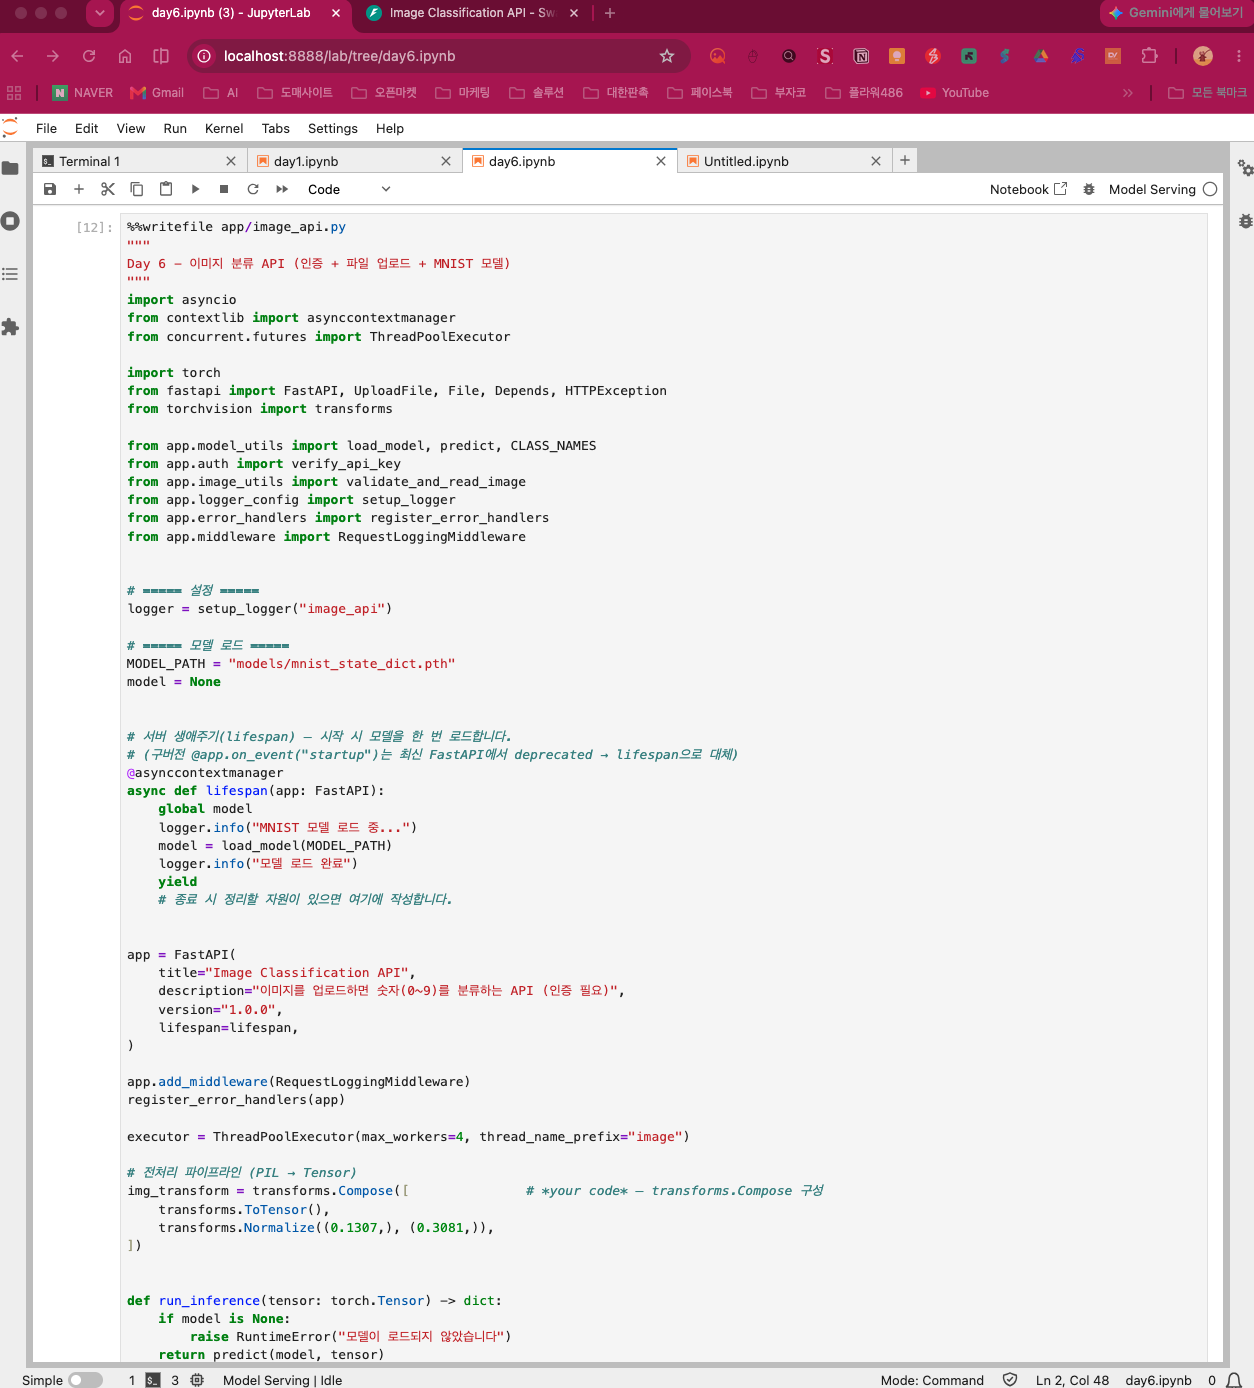

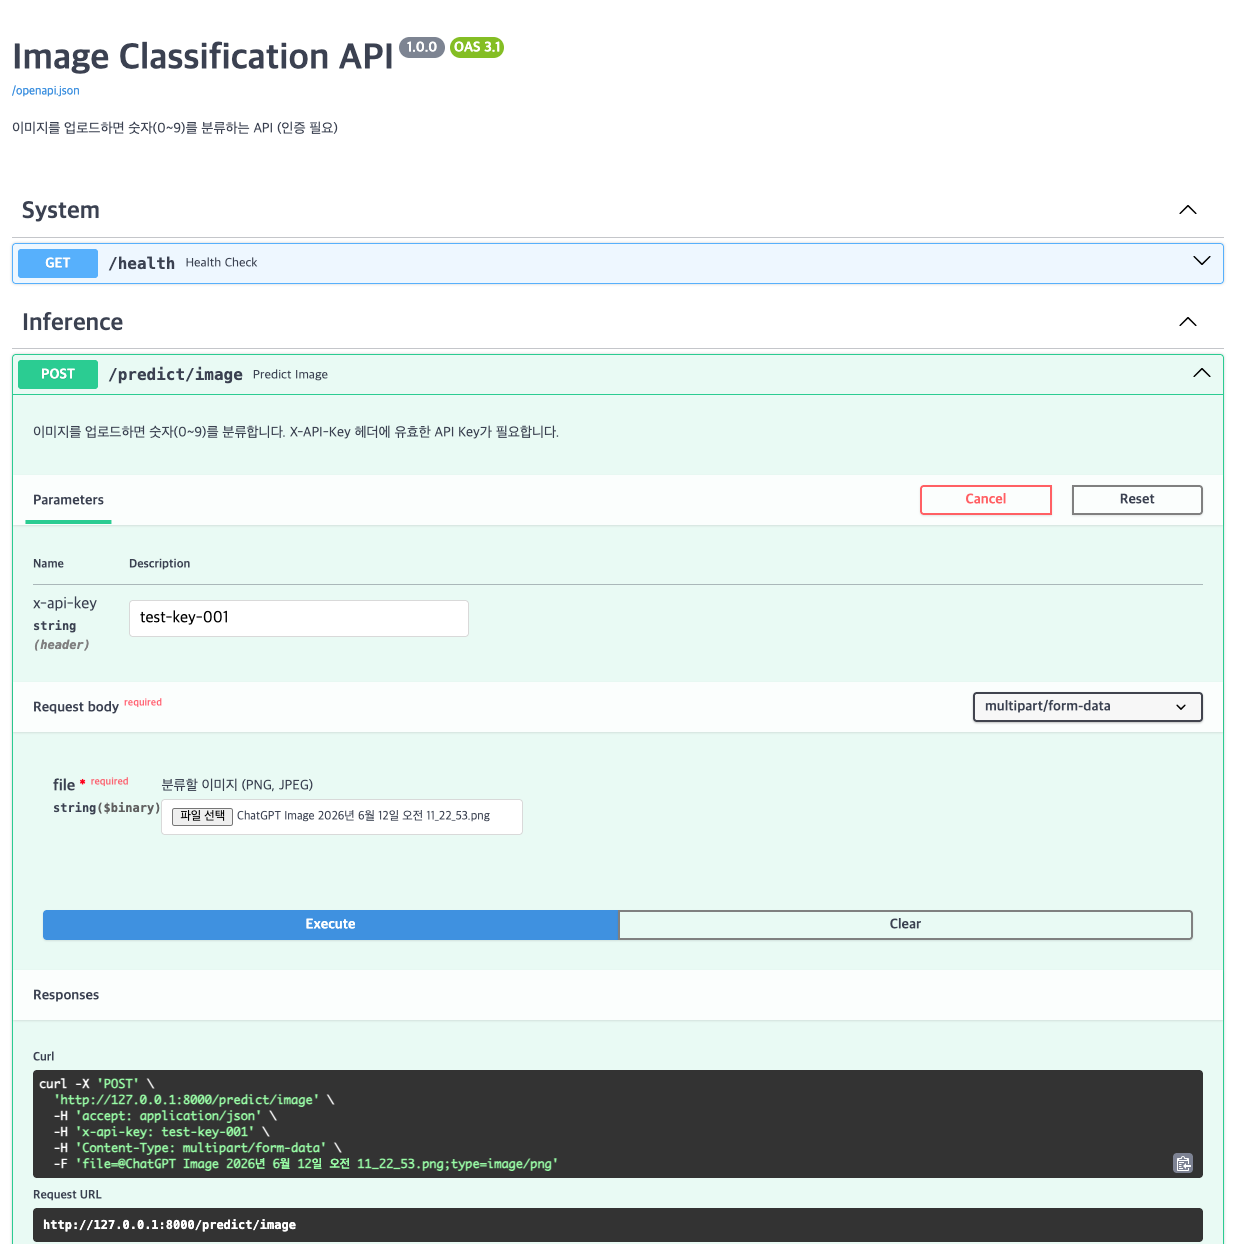